In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-colorblind")
%matplotlib inline

SNOWGLOBES_ROOT = Path("..").resolve()     # if notebook lives in snowglobes/plots/
FLUX_DIR = SNOWGLOBES_ROOT / "fluxes"


In [2]:
def load_flux_table(path: Path):
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] < 2:
        raise ValueError(f"{path} has <2 columns; cannot plot.")
    E = data[:, 0]
    Y = data[:, 1:]
    return E, Y

In [3]:
DEFAULT_LABELS_6FLAV = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$", r"$\bar{\nu}_e$", r"$\bar{\nu}_\mu$", r"$\bar{\nu}_\tau$"]

def plot_flux(path: Path, labels=None, logy=True, title=None):
    E, Y = load_flux_table(path)
    if labels is None:
        labels = DEFAULT_LABELS_6FLAV if Y.shape[1] == 6 else [f"col{i+2}" for i in range(Y.shape[1])]

    fig, ax = plt.subplots(figsize=(7, 5))
    
    for i in range(Y.shape[1]):
        ax.plot(E, Y[:, i], label=labels[i] if i < len(labels) else None)

    
    Sumnue = Y[:, 0].sum()                 # == stpi_flux sumnue
    Sumnumu = Y[:, 1].sum()                 # == stpi_flux sumnue
    Sumnumubar = Y[:, 4].sum()                 # == stpi_flux sumnue
    step_MeV = (np.diff(E)[0] * 1e3)      # convert GeV grid spacing to MeV

    nueflux = Sumnue * (step_MeV / 0.2)  # == stpi_flux flux_per_s_percm2_at_20m
    numuflux = Sumnumu * (step_MeV / 0.2)  # == stpi_flux flux_per_s_percm2_at_20m
    numubarflux = Sumnumubar * (step_MeV / 0.2)  # == stpi_flux flux_per_s_percm2_at_20m
    
    print(f'nue {nueflux:.3e} /cm^2/s')
    print(f'numu {numuflux:.3e} /cm^2/s')
    print(f'numubar {numubarflux:.3e} /cm^2/s')


    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("Flux (file units)")
    if logy:
        ax.set_yscale("log")
    ax.grid(True, which="both", ls=":")
    ax.legend()
    ax.set_title(title or path.name)
    ax.set_xlim(0, 0.06)


    return fig, ax

nue 1.498e+07 /cm^2/s
numu 1.497e+07 /cm^2/s
numubar 1.492e+07 /cm^2/s


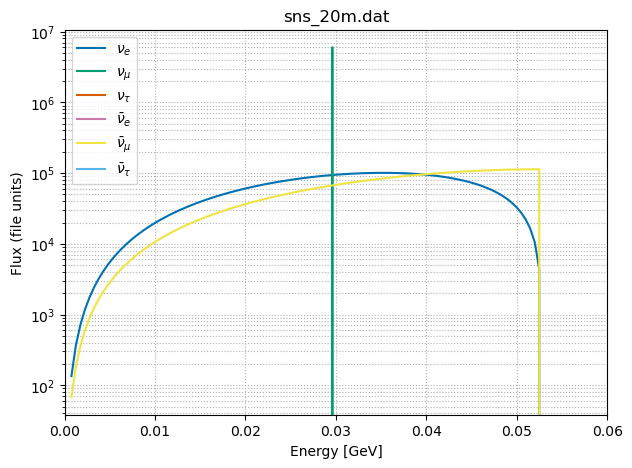

In [6]:
flux_file = FLUX_DIR / "sns_ppu_20m.dat"
flux_file = FLUX_DIR / "sns_20m.dat"
fig, ax = plot_flux(flux_file, logy=-True)